In [3]:
import numpy as np
import bilby
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import scipy.interpolate as interpolate
import scipy.stats as stats
from scipy.integrate import cumulative_simpson

import jax
import jax.numpy as jnp
from jax.scipy.special import erf

from astropy.cosmology import Planck18, z_at_value
import astropy.units as u
from nmma.core.conversion import luminosity_distance_to_redshift
from bilby.gw.conversion import component_masses_to_chirp_mass


events = pd.read_csv("./events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

source = 80
posterior = np.load(f"./gw_posteriors/source_{source}/posterior.npz")
posterior_mm = np.load(f"./gw_posteriors/source_{source}/posterior_mm.npz")

/home/koehn1/miniconda3/envs/nmma_x_fiesta/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# corresponds to 40 and 8000 Mpc
redshift_prior = bilby.gw.prior.UniformSourceFrame(name='redshift', minimum=0.008966150804313566, maximum=1.1421224848725744)
z_arr = redshift_prior.xx
integrand_arr = (1+z_arr)**2 * redshift_prior.yy
antiderivative_arr = cumulative_simpson(x=z_arr, y=integrand_arr, initial=0)

z_arr = jnp.array(z_arr)
antiderivative_arr = jnp.array(antiderivative_arr)

def integral_over_redshift_prior(zmin, zmax):
    """
    This function here implements the integral
    over \pi(z) (1+z)^2 from zmin to zmax
    for the UniformSourceFrame prior we used during the GW inference.
    """
    upper = jnp.interp(zmax, z_arr, antiderivative_arr)
    lower = jnp.interp(zmin, z_arr, antiderivative_arr)
    return upper - lower

def get_logprior(src: int):

    chirp_mass_detector = events.loc[src, "chirp_mass"]

    def logprior_fn(m1, m2):

        chirp_mass_source = (m1*m2)**0.6 / (m1+m2)**0.2
        q = m2/m1

        zmin = (chirp_mass_detector - 0.01) / chirp_mass_source -1
        zmax = (chirp_mass_detector + 0.01) / chirp_mass_source - 1
        zmin = jnp.maximum(z_arr[0], zmin)
        zmax = jnp.minimum(z_arr[-1], zmax)

        constraint = 0.4 <= q 
        constraint &= q <= 1.0
        constraint &= zmin < zmax # can happen if both zmin and zmax are over the limit

        integral = integral_over_redshift_prior(zmin, zmax)
        integral = jnp.maximum(1e-10, integral)


        logprior = jnp.log(integral)

        return jax.lax.select(constraint, logprior, 0.0)
    
    return logprior_fn

In [17]:
def mass_source_frame_samples(prior, mm=False):
    samples = prior.sample(1_000_000)

    m1, m2 = bilby.gw.conversion.chirp_mass_and_mass_ratio_to_component_masses(samples["chirp_mass"], samples["mass_ratio"])
    if not mm:
        redshift = luminosity_distance_to_redshift(samples["luminosity_distance"])
    else:
        redshift = np.random.normal(loc=events.loc[source, "redshift"], scale=0.01 * events.loc[source, "redshift"], size=1_000_000)
    
    return m1  / (1+redshift), m2  / (1+redshift)


In [18]:
MCHIRP = events.loc[source, "chirp_mass"]
prior = bilby.gw.prior.PriorDict("./gw_posteriors/bns.prior")
prior["chirp_mass"] = bilby.gw.prior.UniformInComponentsChirpMass(MCHIRP-0.01, MCHIRP+0.01)
del prior["chi_1"]
del prior["chi_2"]
del prior["lambda_1"]
del prior["lambda_2"]
del prior["psi"]
del prior["phase"]
del prior["theta_jn"]

In [19]:
m1, m2 = mass_source_frame_samples(prior)
m1_mm, m2_mm = mass_source_frame_samples(prior, mm=True)

## GW only

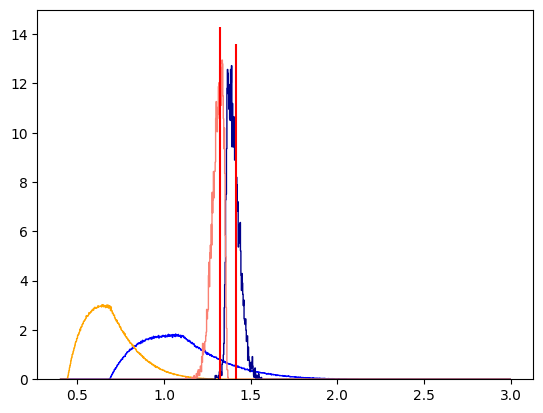

In [124]:

plt.hist(m1, density=True, histtype="step", color="blue", bins=bins)
plt.hist(m2, density=True, histtype="step", color="orange", bins=bins)

plt.hist(posterior["mass_1_source"], histtype="step", color="darkblue", bins=bins, density=True)
plt.hist(posterior["mass_2_source"], histtype="step", color="salmon", bins=bins, density=True)


plt.vlines([events.loc[source, "mass_1_source"]], *plt.gca().get_ylim(), color="red")
plt.vlines([events.loc[source, "mass_2_source"]], *plt.gca().get_ylim(), color="red")

plt.show()


In [154]:
def generate_fake_prior(chirp_mass_detector):

    def fake_prior(m1, m2):
        q = m2/m1
        chirp_mass_source = (m1*m2)**0.6 / (m1+m2)**0.2

        zmin = (chirp_mass_detector - 0.01) / chirp_mass_source -1 
        zmax = (chirp_mass_detector + 0.01) / chirp_mass_source - 1

        z_arr = np.linspace(zmin, zmax, 100)
        y_arr = (1+z_arr)**2 * np.exp(redshift_prior.ln_prob(z_arr))

        constraints = 0.4 <= q <= 1.
        constraints &= zmin < zmax


        return np.where(constraints, np.trapezoid(x=z_arr, y=y_arr), 0)


    return fake_prior

fake_prior_old = generate_fake_prior(events.loc[source, "chirp_mass"])

In [5]:
analytical_prior = get_logprior(source)

In [156]:
nbins = 80
bins = np.linspace(0.4, 3, nbins)
hist, xedges, yedges = np.histogram2d(m1, m2, bins=bins, density=True)
xedges = 0.5 * (xedges[:-1] + xedges[1:])
yedges = 0.5 * (yedges[:-1] + yedges[1:])

bilby_prior = interpolate.RegularGridInterpolator(points=(xedges, yedges), values=hist)

In [6]:
np.exp(analytical_prior(events.loc[source, "mass_1_source"], events.loc[source, "mass_2_source"]))

np.float32(0.0008672805)

In [158]:
bilby_prior((events.loc[source, "mass_1_source"], events.loc[source, "mass_2_source"])) / fake_prior_old(events.loc[source, "mass_1_source"], events.loc[source, "mass_2_source"])

np.float64(33.627724167684505)

In [69]:
factors = np.zeros(1000)

for j in range(1000):
    factors[j] = bilby_prior((posterior["mass_1_source"][j], posterior["mass_2_source"][j])) / np.exp(fake_prior(posterior["mass_1_source"][j], posterior["mass_2_source"][j]))

In [70]:
factors_prior = np.zeros(1000)

for j in range(1000):
    factors_prior[j] = bilby_prior((m1[j], m2[j])) / np.exp(fake_prior(m1[j], m2[j]))

(15.0, 40.0)

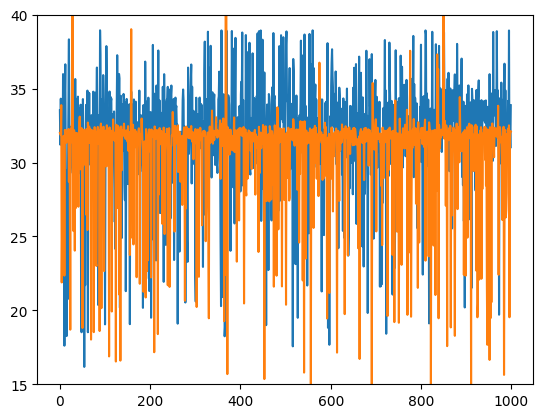

In [71]:
plt.plot(factors)
plt.plot(factors_prior)
plt.ylim((15, 40))

/tmp/ipykernel_1188501/2993415848.py:7: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xedges, yedges, hist, colors="blue", levels=5, label="bilby", linestyles="solid")
/tmp/ipykernel_1188501/2993415848.py:8: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xedges, yedges, hist_fake*32, colors="green", levels=5, label="formula", linestyles="solid")


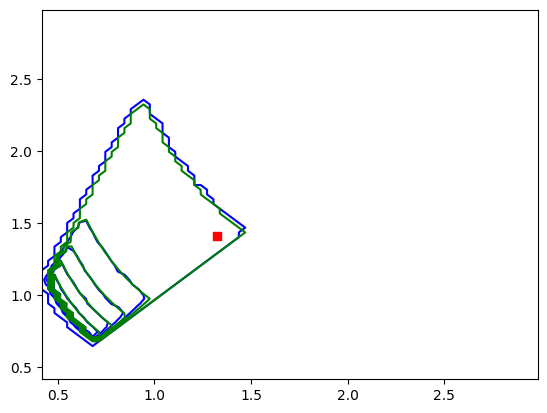

In [166]:
hist_fake = np.zeros((nbins-1, nbins-1))

for j in range(nbins-1):
    for k in range(nbins-1):
        hist_fake[j, k] = np.exp(analytical_prior(xedges[j], yedges[k]))

plt.contour(xedges, yedges, hist, colors="blue", levels=5, label="bilby", linestyles="solid")
plt.contour(xedges, yedges, hist_fake*32, colors="green", levels=5, label="formula", linestyles="solid")
plt.scatter(events.loc[source, "mass_2_source"], events.loc[source, "mass_1_source"], color="red", marker="s")

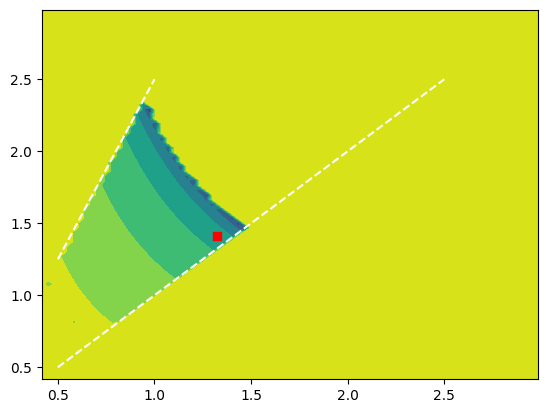

In [174]:
log_hist_fake = np.zeros((nbins-1, nbins-1))

for j in range(nbins-1):
    for k in range(nbins-1):
        log_hist_fake[j, k] = analytical_prior(xedges[j], yedges[k])
    
plt.contourf(xedges, yedges, log_hist_fake)
plt.scatter(events.loc[source, "mass_2_source"], events.loc[source, "mass_1_source"], color="red", marker="s")
plt.plot(np.linspace(0.5, 2.5, 100), np.linspace(0.5, 2.5, 100), color="white", linestyle="dashed")
plt.plot(np.linspace(0.5, 1, 100), 1/0.4 * np.linspace(0.5, 1, 100), color="white", linestyle="dashed")

In [171]:
np.unique(np.sort(log_hist_fake.flatten()))

array([-2.00000000e+05, -9.97562027e+00, -9.90916252e+00, -9.81887245e+00,
       -9.70866966e+00, -9.61937904e+00, -9.54735088e+00, -9.52387524e+00,
       -9.52218056e+00, -9.50796604e+00, -9.43399048e+00, -9.38608456e+00,
       -9.35059071e+00, -9.32533073e+00, -9.25090885e+00, -9.24960327e+00,
       -9.21069145e+00, -9.17448044e+00, -9.14585209e+00, -9.12878227e+00,
       -8.99618149e+00, -8.97006226e+00, -8.91061020e+00, -8.89422417e+00,
       -8.87600040e+00, -8.86252785e+00, -8.78149605e+00, -8.76225281e+00,
       -8.73789692e+00, -8.69219589e+00, -8.57970238e+00, -8.56939030e+00,
       -8.55995941e+00, -8.54921341e+00, -8.52402401e+00, -8.45270443e+00,
       -8.42423534e+00, -8.40317631e+00, -8.37848854e+00, -8.34943867e+00,
       -8.34190273e+00, -8.31642342e+00, -8.31177807e+00, -8.26895714e+00,
       -8.21818733e+00, -8.17345524e+00, -8.10305119e+00, -8.06411552e+00,
       -8.04076481e+00, -8.02010441e+00, -8.01672840e+00, -7.98334122e+00,
       -7.98292780e+00, -

/tmp/ipykernel_1188501/2991835193.py:1: RuntimeWarning: divide by zero encountered in divide
  ratio = hist / hist_fake
/tmp/ipykernel_1188501/2991835193.py:1: RuntimeWarning: invalid value encountered in divide
  ratio = hist / hist_fake
/tmp/ipykernel_1188501/2991835193.py:7: RuntimeWarning: divide by zero encountered in log
  plt.contourf(xedges, yedges, np.log(ratio))


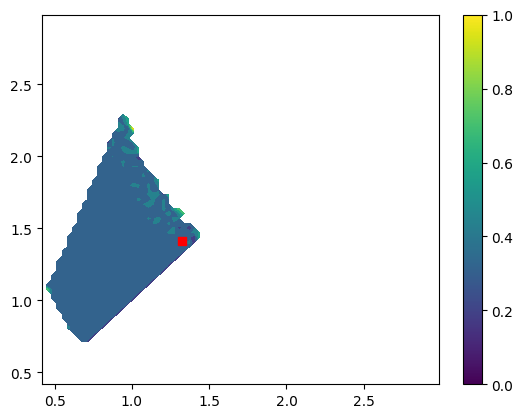

In [73]:
ratio = hist / hist_fake

ratio[np.isnan(ratio)] = 0.
ratio[np.isinf(ratio)] = 0


plt.contourf(xedges, yedges, np.log(ratio))
plt.scatter(events.loc[source, "mass_2_source"], events.loc[source, "mass_1_source"], color="red", marker="s")
plt.colorbar()

In [25]:
jit_prior = jax.jit(analytical_prior)
vmap_prior = jax.vmap(analytical_prior)
from jesterTOV.inference.population.populations import RecycledBinary

params = dict(mu_1=1.34, mu_2=1.43, sigma_1=0.02, sigma_2=0.15, alpha=0.68, m_min=1.16, m_max=1.42, k_coll=1.3)
m1_samp, m2_samp = RecycledBinary(jax.random.key(42), params, size=100_000)

In [189]:
log_prior_arr = np.zeros(100_000)
for j in range(0, 100_000):
     log_prior_arr[j] = jit_prior(m1_samp[j], m2_samp[j])

In [193]:
vmap_prior(m1_samp, m2_samp)

Array([-6.67674823, -6.19755248, -5.15803923, ..., -7.23121394,
       -5.94312364, -6.76928111], dtype=float64)

In [194]:
log_prior_arr

array([-6.67674823, -6.19755248, -5.15803923, ..., -7.23121394,
       -5.94312364, -6.76928111], shape=(100000,))

## MM

In [20]:
bins = np.linspace(0.5, 4, 100)

plt.hist(m1_mm, density=True, histtype="step", color="blue", bins=bins)
plt.hist(m2_mm, density=True, histtype="step", color="orange", bins=bins)

plt.hist(posterior_mm["mass_1_source"], histtype="step", color="darkblue", bins=bins, density=True)
plt.hist(posterior_mm["mass_2_source"], histtype="step", color="salmon", bins=bins, density=True)


plt.vlines([events.loc[source, "mass_1_source"]], *plt.gca().get_ylim(), color="red")
plt.vlines([events.loc[source, "mass_2_source"]], *plt.gca().get_ylim(), color="red")


In [94]:
def generate_fake_prior(chirp_mass_detector):

    def fake_prior(m1, m2):
        q = m2/m1
        chirp_mass_source = (m1*m2)**0.6 / (m1+m2)**0.2

        zmin = (chirp_mass_detector - 0.01) / chirp_mass_source -1
        zmax = (chirp_mass_detector + 0.01) / chirp_mass_source - 1

        z_arr = np.linspace(zmin, zmax, 100)
        y_arr = (1+z_arr)**2 * stats.norm.pdf(z_arr, loc=events.loc[source, "redshift"], scale=0.01 * events.loc[source, "redshift"])

        constraints = 0.4 <= q <= 1.
        constraints &= zmin < zmax


        return np.where(constraints, np.trapezoid(x=z_arr, y=y_arr), 0)


    return fake_prior

fake_prior_old = generate_fake_prior(events.loc[source, "chirp_mass"])

In [8]:
def antiderivative(z, mu, sigma):
    """
    This function here implements the integral
    over \pi(z) (1+z)^2 from zmin to zmax
    for the normal redshift prior used for multi-messenger events.
    """

    term1 = jnp.sqrt(jnp.pi) / jnp.sqrt(2) * sigma  * ( sigma**2 + (mu+1)**2) * erf((z-mu)/(jnp.sqrt(2)*sigma))
    term2 = sigma**2 * (z + mu + 2) * jnp.exp(-0.5 * (z-mu)**2 / sigma**2)

    return term1 - term2


def get_logprior(src: int):

    chirp_mass_detector = events.loc[src, "chirp_mass"]
    redshift_mean = events.loc[src, "redshift"]
    redshift_sigma = 0.01 * redshift_mean

    def logprior_fn(m1, m2):

        chirp_mass_source = (m1*m2)**0.6 / (m1+m2)**0.2
        q = m2/m1

        zmin = (chirp_mass_detector - 0.01) / chirp_mass_source -1
        zmax = (chirp_mass_detector + 0.01) / chirp_mass_source - 1


        constraint = 0.4 <= q 
        constraint &= q <= 1.0

        upper = antiderivative(zmax, redshift_mean, redshift_sigma)
        lower = antiderivative(zmin, redshift_mean, redshift_sigma)
        integral = upper - lower 
        integral = jnp.where(integral<1e-10, 1, integral)
        logprior = jnp.log(integral)
        return jax.lax.select(constraint, logprior, 0.0)
    
    return logprior_fn


analytical_prior = get_logprior(source)

In [21]:
nbins = 1000
bins = np.linspace(0.4, 3, nbins)
hist, xedges, yedges = np.histogram2d(m1_mm, m2_mm, bins=bins, density=True)
xedges = 0.5 * (xedges[:-1] + xedges[1:])
yedges = 0.5 * (yedges[:-1] + yedges[1:])

bilby_prior = interpolate.RegularGridInterpolator(points=(xedges, yedges), values=hist)

In [280]:
bilby_prior((events.loc[source, "mass_1_source"], events.loc[source, "mass_2_source"]))

array(40.10111964)

In [22]:
np.exp(analytical_prior(events.loc[source, "mass_1_source"], events.loc[source, "mass_2_source"]))

np.float32(0.0022187775)

In [282]:
factors = np.zeros(1000)

for j in range(1000):
    factors[j] = bilby_prior((posterior_mm["mass_1_source"][j], posterior_mm["mass_2_source"][j])) / jnp.exp(analytical_prior(posterior_mm["mass_1_source"][j], posterior_mm["mass_2_source"][j]))

In [283]:
factors_prior = np.zeros(1000)

for j in range(1000):
    factors_prior[j] = bilby_prior((m1_mm[j], m2_mm[j])) / jnp.exp(analytical_prior(m1_mm[j], m2_mm[j]))

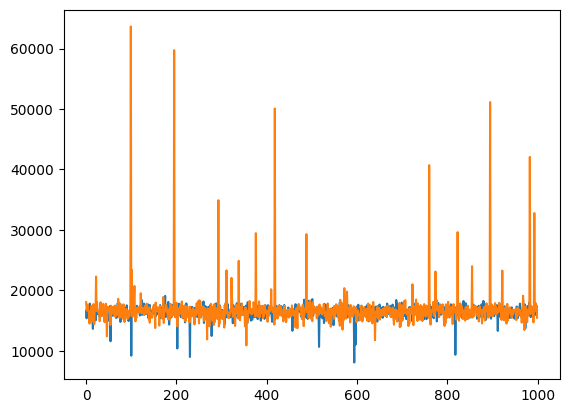

In [284]:
plt.plot(factors)
plt.plot(factors_prior)


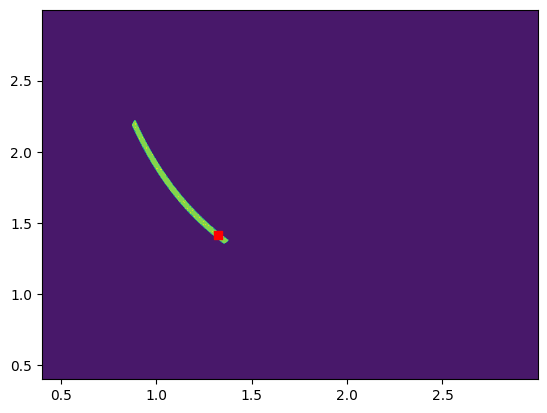

In [285]:
plt.contourf(xedges, yedges, (hist))
plt.scatter(events.loc[source, "mass_2_source"], events.loc[source, "mass_1_source"], color="red", marker="s")

In [14]:
jit_prior = jax.jit(analytical_prior)
vmap_prior = jax.vmap(analytical_prior)

In [23]:
hist_fake = np.zeros((nbins-1, nbins-1))

for j in range(nbins-1):
    for k in range(nbins-1):
        hist_fake[j, k] = jit_prior(xedges[j], yedges[k])
    
plt.contourf(xedges, yedges, (hist_fake))
plt.scatter(events.loc[source, "mass_2_source"], events.loc[source, "mass_1_source"], color="red", marker="s")

In [26]:
log_prior_arr = np.zeros(100_000)
for j in range(0, 100_000):
     log_prior_arr[j] = jit_prior(m1_samp[j], m2_samp[j])

In [289]:
vmap_prior(m1_samp, m2_samp)

Array([  0.        ,   0.        ,   0.        , ...,  -6.11690153,
         0.        , -14.37943568], dtype=float64)

In [29]:
np.unique(np.sort(log_prior_arr))

array([-23.0243593 , -23.02383084, -23.02133857, ...,  -6.11079891,
        -6.11079891,   0.        ], shape=(14041,))

In [30]:
np.exp(-6.11)

np.float64(0.002220550812798294)